In [1]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import fsps
from jax import jit
from tqdm import tqdm
import sedpy_jax as sed
from sedpy_jax.observate import FilterSet as FSjax
from sedpy.observate import FilterSet as FilterSet
from astropy import constants as const
tiny_number = 1e-70

from ceridwen.ssps.ssp_data import SSPData
from ceridwen.csp.csp import CSPBasis, fnu2flam

T_UNIV = 13.8  # Gyr, age of the universe
N_T = 100     # number of time steps for SFH

def gaussian_burst(tau, center_tau, width_tau, amp=1.0):
    """Gaussian in lookback time, evaluated on tau grid (Gyr)."""
    return amp * jnp.exp(-0.5 * ((tau - center_tau) / width_tau)**2)

t = jnp.linspace(1e-2, T_UNIV, N_T)   # Gyr (avoid exactly 0)
tau = T_UNIV - t                      # lookback time (Gyr)

sfr_bimodal = (gaussian_burst(tau, 0.05, 0.03, 1.0) +
               gaussian_burst(tau, 11.0, 0.8, 0.7))
zh = jnp.full_like(t, 10**-4.3477116)  # constant metallicity (Z=0.02)

ssp_data = SSPData.load('/Users/amanda/Desktop/PhD/Tools/ceridwen/ceridwen/data/test_data/ssp_data.h5')

ssp_data.ssp_flux.shape




(12, 108, 5994)

In [2]:
fset = FSjax(['sdss_u0', 'sdss_g0', 'sdss_r0', 'sdss_i0', 'sdss_z0', 'wise_w1', 'wise_w2', 'jwst_f150w', 'jwst_f200w', 'jwst_f277w', 'jwst_f356w', 'jwst_f444w'])

NameError: name 'csp_dust' is not defined

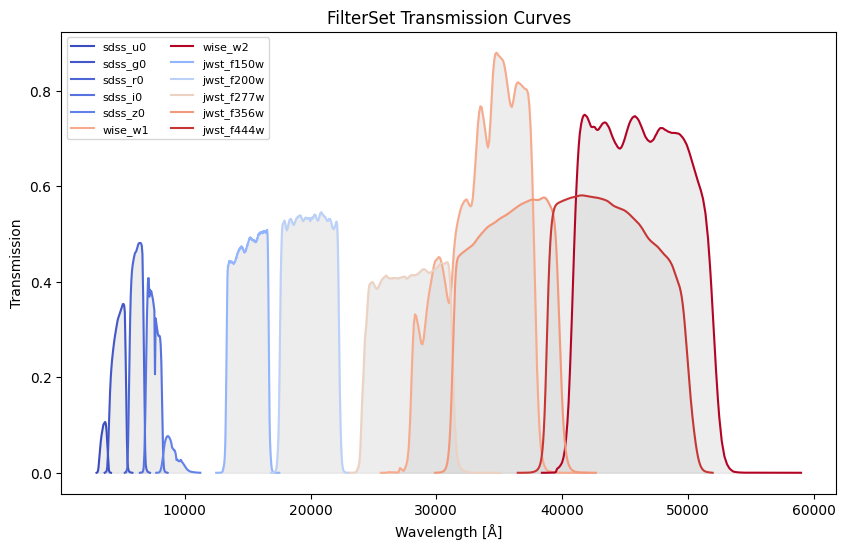

In [3]:
fset.display(normalize=False, colormap='coolwarm')

plt.plot(csp_dust.wave, spec_young_csp_emi, label='Diffuse Dust Only + Emission')
plt.plot(wave_length, maggies, 'o')

plt.xlim(0, 120000)
plt.yscale('log')


In [4]:

diffdust = 0.2
diffdust_index = -0.7
young_dust = 0.2
young_dust_index = -1

csp_dust = CSPBasis(ssp_data, theta_dict = {'lookback_time': tau, 'sfh': sfr_bimodal, 'zh': zh}, tuniv = 13.8, tiny_logt = -70, zh_const = False,
                 add_neb = False, init_neb_params = {"isoc_type": "mist", "cloudy_dust": True}, 
                 add_dust = True, add_diffuse_dust = True, add_dust_emission = True, sps_home = '/Users/amanda/Prospector/fsps',
                 init_dust_params = {'bin_edges': [(-jnp.inf, -1.97)], 
                                'laws': ['powerlaw']}, verbose = True)


def run_spectrum(csp, theta):
    return csp.get_spectrum(theta)

# --- Compile the function, marking `csp` as static
run_spectrum_jit = jit(run_spectrum, static_argnums=0)

#-------------------------------
# CSP SPECTRUM WITH DUSTFREE
#-------------------------------

theta = jnp.array(csp_dust.theta_init.at[csp_dust.tau_pow_idx].set(0))
theta = jnp.array(theta.at[csp_dust.alpha_idx].set(0))
theta = jnp.array(theta.at[csp_dust.diffuse_dust_index_idx].set(0))
theta = jnp.array(theta.at[csp_dust.diffuse_tau_kc_idx].set(0))

spec_dustfree_csp = run_spectrum_jit(csp_dust, theta)

#-------------------------------
# CSP SPECTRUM WITH DIFFUSE DUST ONLY and Emission
#-------------------------------

theta = jnp.array(csp_dust.theta_init.at[csp_dust.tau_pow_idx].set(0))
theta = jnp.array(theta.at[csp_dust.alpha_idx].set(0))
theta = jnp.array(theta.at[csp_dust.diffuse_dust_index_idx].set(diffdust_index))
theta = jnp.array(theta.at[csp_dust.diffuse_tau_kc_idx].set(diffdust))

spec_diffuse_csp_emi = run_spectrum_jit(csp_dust, theta)

#-------------------------------
# CSP SPECTRUM WITH YOUNG DUST ONLY and Emission
#-------------------------------

theta = jnp.array(csp_dust.theta_init.at[csp_dust.tau_pow_idx].set(young_dust))
theta = jnp.array(theta.at[csp_dust.alpha_idx].set(young_dust_index))
theta = jnp.array(theta.at[csp_dust.diffuse_dust_index_idx].set(0))
theta = jnp.array(theta.at[csp_dust.diffuse_tau_kc_idx].set(0))

spec_young_csp_emi = run_spectrum_jit(csp_dust, theta)
#-------------------------------
# CSP SPECTRUM WITH ALL DUST and Emission
#-------------------------------

theta = jnp.array(csp_dust.theta_init.at[csp_dust.tau_pow_idx].set(young_dust))
theta = jnp.array(theta.at[csp_dust.alpha_idx].set(young_dust_index))
theta = jnp.array(theta.at[csp_dust.diffuse_dust_index_idx].set(diffdust_index))
theta = jnp.array(theta.at[csp_dust.diffuse_tau_kc_idx].set(diffdust))

spec_dust_csp_emi = run_spectrum_jit(csp_dust, theta)

Using combined (binwise + diffuse) dust attenuation.
Initializing Dust attenuation model...
Initializing DiffuseDust model...
Initializing DustEmission model...
Dust initialization complete.
Get spectrum with dust attenuation, without nebular contribution, and with dust emission.
dict_keys(['sfh_times', 'sfh', 'theta_init', 'alpha_idx', 'diffuse_dust_index_idx', 'diffuse_tau_kc_idx', 'duste_gamma_idx', 'duste_qpah_idx', 'duste_umin_idx', 'sfh_idx', 'tau_pow_idx', 'zh_idx'])


In [5]:
def fnu2flam(lam, fnu):
    """Convert f_nu [erg/s/cm^2/Hz] to f_lambda [erg/s/cm^2/Å]."""
    c = 2.998e18  # Å/s
    return c * (fnu / (lam**2))

In [6]:
def get_maggies(fset, flux, sourcewave):
    return fset.get_sed_maggies(flux, sourcewave)

# --- Compile the function, marking `fset` as static
get_maggies_jit = jit(get_maggies, static_argnums=0)

In [7]:
spec_lam = fnu2flam(csp_dust.wave, spec_dustfree_csp)
spec_lam_dust = fnu2flam(csp_dust.wave, spec_dust_csp_emi)
maggies_dusty = get_maggies_jit(fset,spec_lam_dust, sourcewave=csp_dust.wave)
maggies_dustfree = get_maggies_jit(fset, spec_lam, sourcewave=csp_dust.wave)
wave_length = [f.wave_effective for f in fset.filters]
maggies

NameError: name 'maggies' is not defined

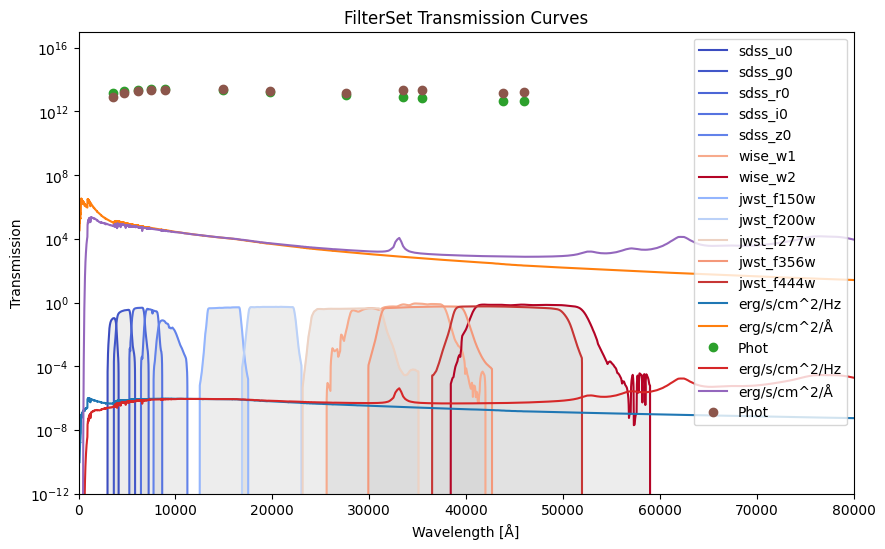

In [8]:

fset.display(normalize=False, colormap='coolwarm')
plt.plot(csp_dust.wave, spec_dustfree_csp , label='erg/s/cm^2/Hz')
plt.plot(csp_dust.wave, spec_lam, label= 'erg/s/cm^2/Å')
plt.plot(wave_length, maggies_dustfree, 'o', label= 'Phot')

plt.plot(csp_dust.wave, spec_dust_csp_emi , label='erg/s/cm^2/Hz')
plt.plot(csp_dust.wave, spec_lam_dust, label= 'erg/s/cm^2/Å')
plt.plot(wave_length, maggies_dusty, 'o', label= 'Phot')

plt.xlim(0, 80000)
plt.yscale('log')

plt.ylim(1e-12, 1e17)

plt.legend()

# CERIDWEN IMPORT

In [9]:
from ceridwen.observation import Photometry

In [10]:
from ceridwen.observation import Photometry

# example: one photometry observation using your FSjax filter set
fset = FSjax([
    'sdss_u0','sdss_g0','sdss_r0','sdss_i0','sdss_z0',
    'wise_w1','wise_w2',
    'jwst_f150w','jwst_f200w','jwst_f277w',
    'jwst_f356w','jwst_f444w'
])

flux = fset.get_sed_maggies(sourceflux = spec_dustfree_csp, sourcewave = csp_dust.wave)

phot = Photometry(
    filters=[f.name for f in fset.filters],  # names
    flux=flux,
    uncertainty=flux * 0.1, # dummy
    mask=jnp.ones(len(fset.filters), dtype=bool),
    name="phot_JADES"
)

(100.0, 100000.0)

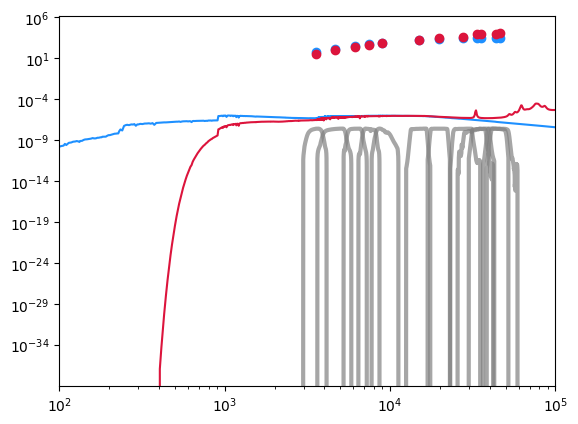

In [13]:
plt.loglog(csp_dust.wave, spec_dustfree_csp, color = 'dodgerblue')
plt.loglog(phot.wavelength, phot.flux, 'o', color = 'dodgerblue')
plt.loglog(csp_dust.wave, spec_dust_csp_emi, color = 'crimson')
new_phot = phot.predict_from_spec(spec = spec_dust_csp_emi, wave = csp_dust.wave)
plt.loglog(phot.wavelength, new_phot, 'o', color = 'crimson')

ymax = 1e-2
ymin = 1e-9
for f in phot.filters:
    w, t = f.wavelength.copy(), f.transmission.copy()
    t = t / t.max()
    t = 10**(0.2*(np.log10(ymax/ymin)))*t * ymin
    plt.loglog(w, t, lw=3, color='gray', alpha=0.7)

#plt.ylim(1e-10, 1e-5)
plt.xlim(1e2, 1e5)

In [ ]:
phot.filterset.get_sed_maggies(sourceflux = spec_dust_csp_emi, sourcewave = csp_dust.wave)


Array([   35.086205,   110.537834,   244.04355 ,   412.22964 ,
         626.3984  ,  8066.8604  , 11903.714   ,  1810.3441  ,
        2498.1555  ,  3631.0464  ,  8770.745   ,  9389.743   ],      dtype=float32)

In [14]:
import jax
import jax.numpy as jnp

# wrapper: only numeric arguments go inside
def predict_wrapper(spec, wave):
    return phot.predict_from_spec(spec=spec, wave=wave)

predict_jit = jax.jit(predict_wrapper)

# call it
maggies = predict_jit(spec_dust_csp_emi, csp_dust.wave)